In [1]:
import random, math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, random_clifford, negativity, DensityMatrix, partial_trace
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
 
from qiskit_aer.noise import NoiseModel, depolarizing_error

In [2]:
# Prepare a GHZ state

def GHZ_state(circuit, L):
    circuit.h(0)
    for qubit in range(1, L):
        circuit.cx(0, qubit)

# Depolarizing channel function

def random_depolarizing_channel(L):
    for i in range(L):
            depolarizingchannel = random_clifford(1, seed=None)
            circuit.unitary(depolarizingchannel, [i], label="dp")
        
# Clifford gate random brickwork circuit function

def random_brickwork_circuit(L):
    global circuit
    circuit = QuantumCircuit(L, L**2)
    GHZ_state(circuit, L)

    for t in range(L*2):
        circuit.save_density_matrix(label=f"dm_{t}")
        random_depolarizing_channel(L)
        if t % 2 == 0:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                circuit.unitary(gate, [2*i, 2*i+1], label=" ")
        else:
            for i in range(int(L/2)):
                gate = random_clifford(2, seed=None,)
                if 2*i == L-2:
                    circuit.unitary(gate, [L-1, 0], label=" ")
                else:
                    circuit.unitary(gate, [2*i+1, 2*i+2], label=" ")

    # circuit.measure_all()
    return circuit

# Logarithmic Negativity Function

def calculate_log_negativity(dm, subsystem):
    rho = DensityMatrix(dm)
    negv = negativity(rho, subsystem)
    log_negv = math.log(2 * negv + 1, 2)
    return log_negv

# Create circuit

# random_brickwork_circuit()

# Draw circuit

# circuit.draw("mpl")

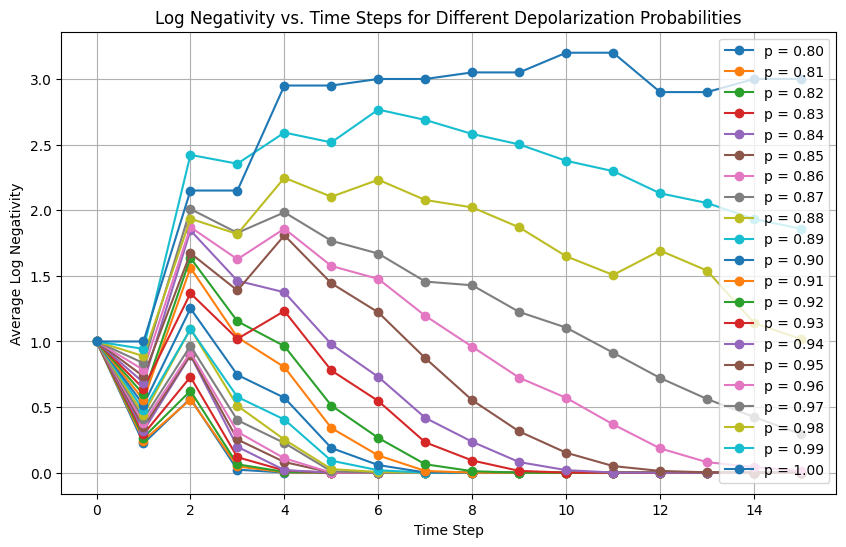

In [3]:
# Number of Qubits and P Value Range

L = 8
p_values = np.arange(0.8, 1.01, 0.01)
time_steps = list(range(L * 2))

num_runs = 20
num_samples = len(time_steps) * num_runs

results = {}
results_std = {}

# Loop over all P Values for fixed Qubit number

for p in p_values:
    final_log_negv = []
    for i in range(num_runs):

        circuit = random_brickwork_circuit(L)
        depo_err_chan = depolarizing_error(round(1-p, 2), 1)

        # Noise model

        noise_model = NoiseModel()
        noise_model.add_basis_gates(['unitary'])
        noise_model.add_all_qubit_quantum_error(depo_err_chan, ["dp"])
        sim_noise = AerSimulator(noise_model=noise_model)

        # Job

        job = sim_noise.run(circuit)
        result = job.result().data()

        # Get Density Matrices

        log_negv_runs = []

        for t in time_steps:

            dm = result.get(f"dm_{t}")

            # Calculate negativity

            log_negv = calculate_log_negativity(dm, list(range(int(L/2))))
            log_negv_runs.append(log_negv)

        final_log_negv.append(log_negv_runs)

    results[p] = np.mean(final_log_negv, axis = 0)
    results_std[p] = np.std(final_log_negv, axis = 0)

# Plot results

plt.figure(figsize=(10, 6))

for p, avg_log_negv in results.items():
    plt.plot(time_steps, avg_log_negv, label=f"p = {p:.2f}", marker ="o")
    
plt.xlabel("Time Step")
plt.ylabel("Average Log Negativity")
plt.title("Log Negativity vs. Time Steps for Different Depolarization Probabilities")
plt.legend()
plt.grid()
plt.show()

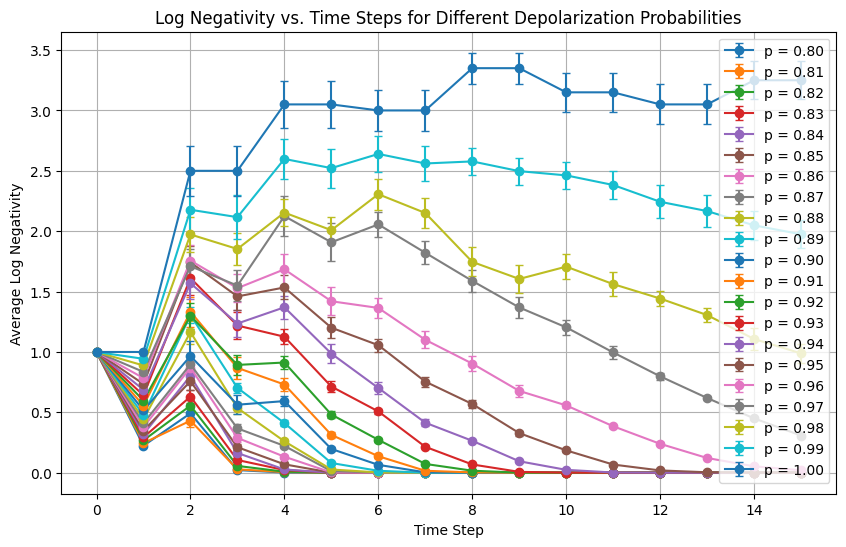

In [13]:
# Calculate Standard Error
results_se = {p: stds / np.sqrt(num_runs) for p, stds in results_std.items()}

# Plot results with error bars
plt.figure(figsize=(10, 6))

for p, avg_log_negv in results.items():
    se = results_se[p]  # Get the standard error for this p-value
    plt.errorbar(time_steps, avg_log_negv, yerr=se, label=f"p = {p:.2f}", marker="o", capsize=3)

# Customize the plot
plt.xlabel("Time Step")
plt.ylabel("Average Log Negativity")
plt.title("Log Negativity vs. Time Steps for Different Depolarization Probabilities")
plt.legend()
plt.grid()
plt.show()